1. Імпорт бібліотек

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore')

# Завантаження стоп-слів
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

2. Завантаження датасету:

In [6]:
df = pd.read_csv('Corona_NLP_train.csv', encoding='latin-1')

# Перегляд перших рядків
print(df.head())
print(f"\nРозмір датасету: {df.shape}")
print(f"\nРозподіл класів:\n{df['Sentiment'].value_counts()}")

   UserName  ScreenName   Location     TweetAt  \
0      3799       48751     London  16-03-2020   
1      3800       48752         UK  16-03-2020   
2      3801       48753  Vagabonds  16-03-2020   
3      3802       48754        NaN  16-03-2020   
4      3803       48755        NaN  16-03-2020   

                                       OriginalTweet           Sentiment  
0  @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...             Neutral  
1  advice Talk to your neighbours family to excha...            Positive  
2  Coronavirus Australia: Woolworths to give elde...            Positive  
3  My food stock is not the only one which is emp...            Positive  
4  Me, ready to go at supermarket during the #COV...  Extremely Negative  

Розмір датасету: (41157, 6)

Розподіл класів:
Sentiment
Positive              11422
Negative               9917
Neutral                7713
Extremely Positive     6624
Extremely Negative     5481
Name: count, dtype: int64


3. Об’єднання початкових 5 класів настрою в три спрощені категорії - Positive, Negative та Neutral і виведення їх розподіл у DataFrame

In [7]:
# Функція для спрощення класів з 5 до 3
def simplify_sentiment(label):
    """Об'єднуємо схожі класи для кращої точності"""
    if 'Positive' in str(label):  # Extremely Positive + Positive
        return 'Positive'
    elif 'Negative' in str(label):  # Extremely Negative + Negative
        return 'Negative'
    else:  # Neutral
        return 'Neutral'

# Застосування спрощення
df['Sentiment'] = df['Sentiment'].apply(simplify_sentiment)

print("\n" + "="*60)
print("СПРОЩЕНІ КЛАСИ")
print("="*60)
print(f"\nНовий розподіл класів:")
print(df['Sentiment'].value_counts())
print(f"\nПроцентне співвідношення:")
print(df['Sentiment'].value_counts(normalize=True) * 100)


СПРОЩЕНІ КЛАСИ

Новий розподіл класів:
Sentiment
Positive    18046
Negative    15398
Neutral      7713
Name: count, dtype: int64

Процентне співвідношення:
Sentiment
Positive    43.846733
Negative    37.412834
Neutral     18.740433
Name: proportion, dtype: float64


4. Попередня обробка тексту

In [8]:

# Функція для очистки тексту
def clean_text(text):
    if pd.isna(text):
        return ""
    # Приведення до нижнього регістру
    text = text.lower()
    # Видалення URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Видалення згадок (@username)
    text = re.sub(r'@\w+', '', text)
    # Видалення хештегів (#hashtag)
    text = re.sub(r'#\w+', '', text)
    # Видалення спецсимволів та цифр
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Видалення зайвих пробілів
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Застосування очистки
df['cleaned_tweet'] = df['OriginalTweet'].apply(clean_text)

# Видалення пустих твітів
df = df[df['cleaned_tweet'].str.len() > 0].reset_index(drop=True)

print(f"Розмір після очистки: {df.shape}")

Розмір після очистки: (41120, 7)


5. Токенізація та видалення стоп-слів

In [9]:
stop_words = set(stopwords.words('english'))

def tokenize_text(text):
    tokens = word_tokenize(text)
    # Видалення стоп-слів та коротких слів
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return tokens

# Токенізація
df['tokens'] = df['cleaned_tweet'].apply(tokenize_text)

# Видалення твітів без токенів
df = df[df['tokens'].apply(len) > 0].reset_index(drop=True)

print(f"Приклад токенізованого тексту:")
print(df['tokens'].iloc[0])

Приклад токенізованого тексту:
['advice', 'talk', 'neighbours', 'family', 'exchange', 'phone', 'numbers', 'create', 'contact', 'list', 'phone', 'numbers', 'neighbours', 'schools', 'employer', 'chemist', 'set', 'online', 'shopping', 'accounts', 'poss', 'adequate', 'supplies', 'regular', 'meds', 'order']


6. Навчання моделі Word2Vec

In [10]:
# Підготовка корпусу для Word2Vec
corpus = df['tokens'].tolist()

# Навчання Word2Vec з покращеними параметрами
print("\n" + "="*60)
print("НАВЧАННЯ WORD2VEC")
print("="*60)

w2v_model = Word2Vec(
    sentences=corpus,
    vector_size=300,      # більша розмірність
    window=10,            # більший контекст
    min_count=1,          # не пропускаємо рідкісні слова
    workers=4,
    epochs=30,            # більше епох навчання
    sg=1,                 # Skip-gram
    negative=10,          # Більше негативних семплів
    alpha=0.025,
    min_alpha=0.0001
)

print(f"\n✓ Навчено Word2Vec:")
print(f"  - Розмір словника: {len(w2v_model.wv)}")
print(f"  - Розмірність векторів: {w2v_model.vector_size}")


НАВЧАННЯ WORD2VEC

✓ Навчено Word2Vec:
  - Розмір словника: 36275
  - Розмірність векторів: 300


7.  Створення векторів для твітів

In [11]:
def get_tweet_vector(tokens, model):
    """Отримання вектора твіту як середнє векторів слів"""
    vectors = []
    for token in tokens:
        if token in model.wv:
            vectors.append(model.wv[token])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

# Створення векторів для всіх твітів
print("\nСтворення Word2Vec векторів для всіх твітів...")
df['w2v_vector'] = df['tokens'].apply(lambda x: get_tweet_vector(x, w2v_model))

X_w2v = np.array(df['w2v_vector'].tolist())
print(f"✓ Word2Vec матриця: {X_w2v.shape}")


Створення Word2Vec векторів для всіх твітів...
✓ Word2Vec матриця: (41099, 300)


8. Створення TF-IDF ознаки з токенізованих текстів, об’єднання їх з Word2Vec векторами в одну матрицю ознак і підготовка її разом з цільовою змінною для моделі


In [12]:
print("\n" + "="*60)
print("ДОДАВАННЯ TF-IDF ОЗНАК")
print("="*60)

# Створення TF-IDF векторизатора
tfidf = TfidfVectorizer(
    max_features=500,      # Топ-500 найважливіших слів
    ngram_range=(1, 2),    # Uni-grams та bi-grams
    min_df=2,              # Слово має з'явитись хоча б у 2 документах
    max_df=0.8             # Ігноруємо слова, що з'являються більш ніж у 80% документів
)

# Підготовка текстів для TF-IDF (об'єднання токенів назад у текст)
df['text_for_tfidf'] = df['tokens'].apply(lambda x: ' '.join(x))

# Створення TF-IDF матриці
X_tfidf = tfidf.fit_transform(df['text_for_tfidf']).toarray()

print(f"✓ TF-IDF матриця: {X_tfidf.shape}")

# Об'єднання Word2Vec + TF-IDF
X_combined = np.hstack([X_w2v, X_tfidf])

print(f"\n✓ Об'єднана матриця ознак: {X_combined.shape}")
print(f"  - Word2Vec ознаки: {X_w2v.shape[1]}")
print(f"  - TF-IDF ознаки: {X_tfidf.shape[1]}")
print(f"  - Разом: {X_combined.shape[1]}")

# Використовуємо об'єднану матрицю
X = X_combined
y = df['Sentiment'].values

print(f"\n✓ Фінальна матриця: {X.shape}")
print(f"✓ Цільова змінна: {y.shape}")


ДОДАВАННЯ TF-IDF ОЗНАК
✓ TF-IDF матриця: (41099, 500)

✓ Об'єднана матриця ознак: (41099, 800)
  - Word2Vec ознаки: 300
  - TF-IDF ознаки: 500
  - Разом: 800

✓ Фінальна матриця: (41099, 800)
✓ Цільова змінна: (41099,)


9.  Розділення на тренувальну та тестову вибірки

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n" + "="*60)
print("РОЗДІЛЕННЯ ДАНИХ")
print("="*60)
print(f"Тренувальна вибірка: {X_train.shape}")
print(f"Тестова вибірка: {X_test.shape}")
print(f"\nРозподіл класів у тренувальній вибірці:")
for label, count in zip(*np.unique(y_train, return_counts=True)):
    print(f"  {label}: {count} ({count/len(y_train)*100:.1f}%)")


РОЗДІЛЕННЯ ДАНИХ
Тренувальна вибірка: (32879, 800)
Тестова вибірка: (8220, 800)

Розподіл класів у тренувальній вибірці:
  Negative: 12317 (37.5%)
  Neutral: 6128 (18.6%)
  Positive: 14434 (43.9%)


10. Визначення моделей

In [14]:
# Моделі з кращими параметрами
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0,
        n_jobs=-1
    ),
    'SVM': SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        random_state=42,
        cache_size=2000
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),
    'Naive Bayes': GaussianNB()
}

11. Навчання без PCA

In [15]:
results = []

print("\n" + "="*60)
print("=== НАВЧАННЯ МОДЕЛЕЙ БЕЗ PCA ===")
print("="*60 + "\n")

for name, model in models.items():
    print(f"Навчання {name}...")

    # Навчання
    model.fit(X_train, y_train)

    # Прогнозування
    y_pred = model.predict(X_test)

    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )

    results.append({
        'Model': name,
        'PCA Components': 'None',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}\n")

# Створення DataFrame з результатами
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("РЕЗУЛЬТАТИ БЕЗ PCA")
print("="*60)
print(results_df.to_string(index=False))


=== НАВЧАННЯ МОДЕЛЕЙ БЕЗ PCA ===

Навчання Logistic Regression...
  ✓ Accuracy: 0.7246
  ✓ F1-Score: 0.7231

Навчання SVM...
  ✓ Accuracy: 0.7506
  ✓ F1-Score: 0.7494

Навчання Random Forest...
  ✓ Accuracy: 0.6369
  ✓ F1-Score: 0.6074

Навчання Naive Bayes...
  ✓ Accuracy: 0.6030
  ✓ F1-Score: 0.6108


РЕЗУЛЬТАТИ БЕЗ PCA
              Model PCA Components  Accuracy  Precision   Recall  F1-Score
Logistic Regression           None  0.724574   0.722588 0.724574  0.723062
                SVM           None  0.750608   0.749797 0.750608  0.749393
      Random Forest           None  0.636861   0.667597 0.636861  0.607359
        Naive Bayes           None  0.603041   0.657266 0.603041  0.610836


12.  Навчання з PCA

In [31]:
# Визначення компонент PCA (адаптивно)
max_components = min(X_train.shape[0], X_train.shape[1])
print(f"\nМаксимальна кількість компонент PCA: {max_components}")

# Вибір розумних значень
if max_components >= 200:
    pca_components = [50, 100, 200]
elif max_components >= 100:
    pca_components = [50, 100]
else:
    pca_components = [50]

print(f"Використовуємо компоненти PCA: {pca_components}")

print("\n" + "="*60)
print("=== НАВЧАННЯ МОДЕЛЕЙ З PCA (через scikit-learn Pipeline) ===")
print("="*60)

for n_components in pca_components:
    print(f"\n{'='*60}")
    print(f"--- PCA з {n_components} компонентами ---")
    print(f"{'='*60}\n")

    if n_components > X_train.shape[1]:
        print(f"УВАГА: {n_components} компонент > {X_train.shape[1]} ознак!")
        n_components = X_train.shape[1]
        print(f"Використовуємо максимум {n_components} компонент\n")

    variance_explained = None  # Ініціалізація, буде підрахована через PCA всередині pipeline

    for name, clf in models.items():
        print(f"Навчання {name} через Pipeline...")

        # Створення Pipeline
        pipeline = Pipeline([
            ('pca', PCA(n_components=n_components, random_state=42)),
            ('clf', clf)
        ])

        # Навчання
        pipeline.fit(X_train, y_train)

        # Прогнозування
        y_pred = pipeline.predict(X_test)

        # Витягнута дисперсія з PCA
        pca_stage = pipeline.named_steps['pca']
        variance_explained = pca_stage.explained_variance_ratio_.sum()

        # Метрики
        accuracy = accuracy_score(y_test, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average='weighted', zero_division=0
        )

        results.append({
            'Model': name,
            'PCA Components': n_components,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'Explained Variance': variance_explained
        })

        print(f"  ✓ Пояснена дисперсія: {variance_explained:.4f} ({variance_explained*100:.2f}%)")
        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}\n")

# DataFrame з результатами
results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("=== ПІДСУМКОВІ РЕЗУЛЬТАТИ З PIPELINE ===")
print("="*80 + "\n")
print(results_df.to_string(index=False))



Максимальна кількість компонент PCA: 800
Використовуємо компоненти PCA: [50, 100, 200]

=== НАВЧАННЯ МОДЕЛЕЙ З PCA (через scikit-learn Pipeline) ===

--- PCA з 50 компонентами ---

Навчання Logistic Regression через Pipeline...
  ✓ Пояснена дисперсія: 0.4048 (40.48%)
  ✓ Accuracy: 0.6024
  ✓ F1-Score: 0.5865

Навчання SVM через Pipeline...
  ✓ Пояснена дисперсія: 0.4048 (40.48%)
  ✓ Accuracy: 0.6478
  ✓ F1-Score: 0.6435

Навчання Random Forest через Pipeline...
  ✓ Пояснена дисперсія: 0.4048 (40.48%)
  ✓ Accuracy: 0.6246
  ✓ F1-Score: 0.6044

Навчання Naive Bayes через Pipeline...
  ✓ Пояснена дисперсія: 0.4048 (40.48%)
  ✓ Accuracy: 0.5669
  ✓ F1-Score: 0.5670


--- PCA з 100 компонентами ---

Навчання Logistic Regression через Pipeline...
  ✓ Пояснена дисперсія: 0.5691 (56.91%)
  ✓ Accuracy: 0.6186
  ✓ F1-Score: 0.6053

Навчання SVM через Pipeline...
  ✓ Пояснена дисперсія: 0.5691 (56.91%)
  ✓ Accuracy: 0.6808
  ✓ F1-Score: 0.6787

Навчання Random Forest через Pipeline...
  ✓ Поясне

13. Побудова лінійного графіку, що показує, як кількість компонентів PCA впливає на точність різних моделей класифікації

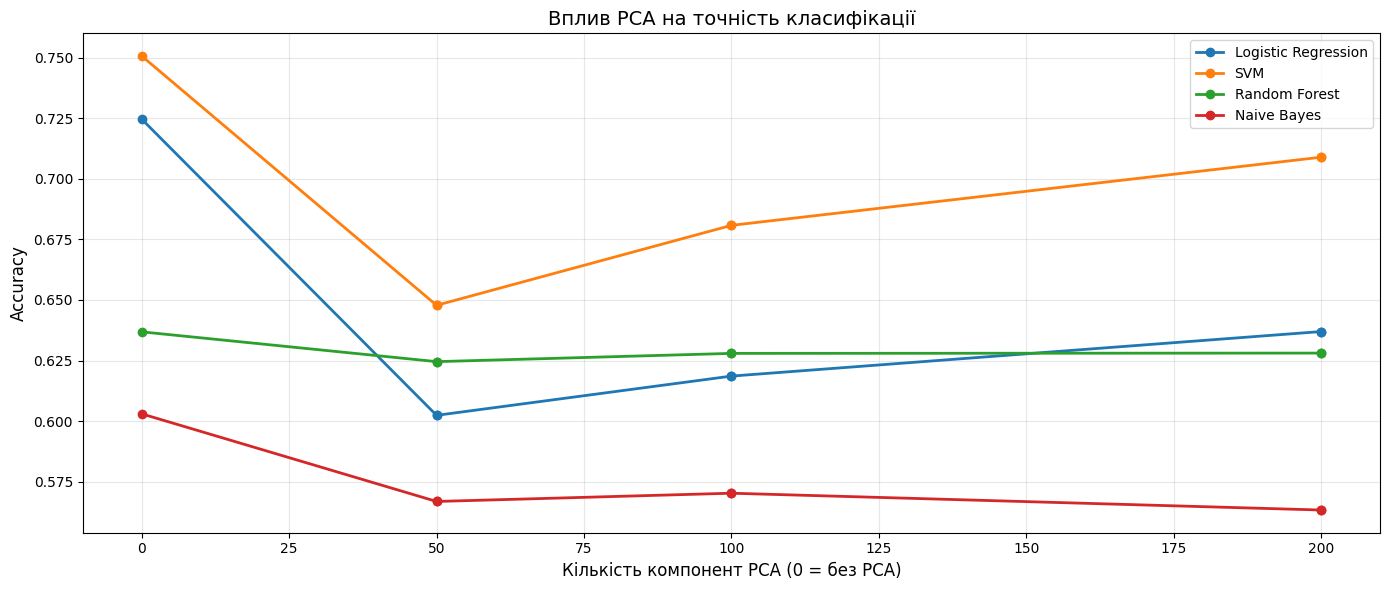

In [33]:
# Графік впливу PCA на точність
plt.figure(figsize=(14, 6))

for model_name in models.keys():
    model_results = results_df[results_df['Model'] == model_name]

    # Отримання значень
    pca_vals = []
    acc_vals = []

    for _, row in model_results.iterrows():
        # Перетворюємо None на 0 і всі інші значення на int
        if row['PCA Components'] in [0, 'None', None]:
            pca_val = 0
        else:
            pca_val = int(row['PCA Components'])
        pca_vals.append(pca_val)
        acc_vals.append(row['Accuracy'])

    # Сортуємо по PCA компонентах
    sorted_pairs = sorted(zip(pca_vals, acc_vals))
    sorted_pca, sorted_acc = zip(*sorted_pairs)

    plt.plot(sorted_pca, sorted_acc, marker='o', label=model_name, linewidth=2)

plt.xlabel('Кількість компонент PCA (0 = без PCA)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Вплив PCA на точність класифікації', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


14. Знаходження моделі з найвищою точністю та перенавчання її (за потреби застосовуючи PCA), прогнозування на тестових даних, візуалізація матриці помилок і виведення детального звіту класифікації



Найкраща модель: SVM
PCA Components: None
Accuracy: 0.7506


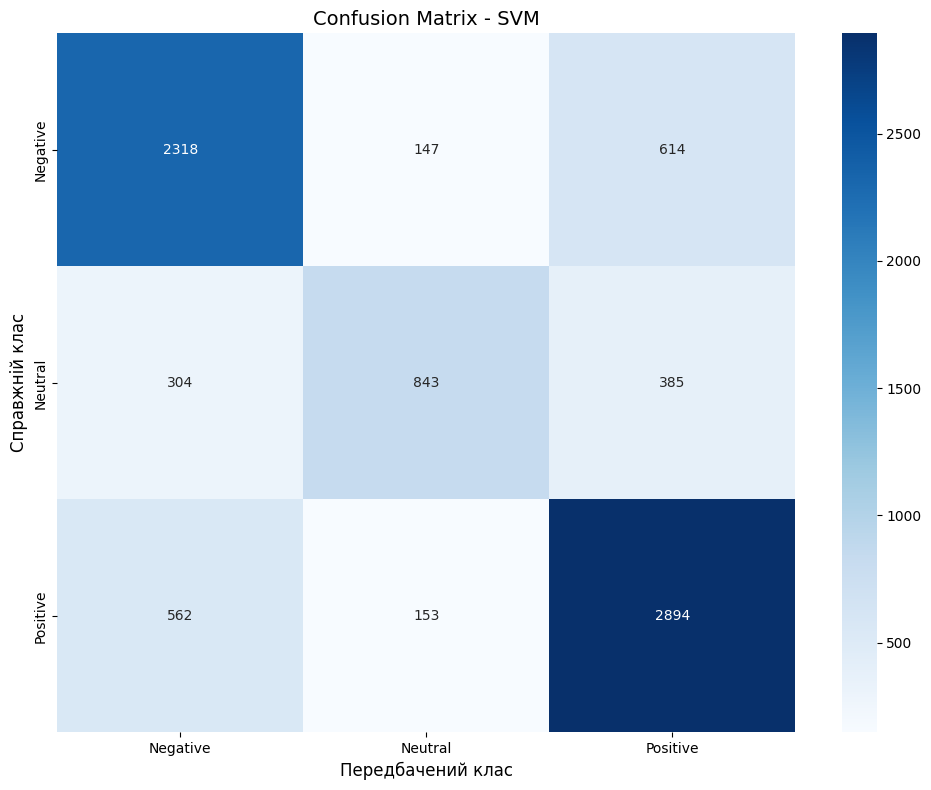


=== Classification Report ===

              precision    recall  f1-score   support

    Negative       0.73      0.75      0.74      3079
     Neutral       0.74      0.55      0.63      1532
    Positive       0.74      0.80      0.77      3609

    accuracy                           0.74      8220
   macro avg       0.74      0.70      0.71      8220
weighted avg       0.74      0.74      0.73      8220



In [18]:
# Знаходження найкращої моделі
best_result = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\nНайкраща модель: {best_result['Model']}")
print(f"PCA Components: {best_result['PCA Components']}")
print(f"Accuracy: {best_result['Accuracy']:.4f}")

# Перенавчання найкращої моделі
best_model_name = best_result['Model']
best_pca = best_result['PCA Components']

if best_model_name == 'Logistic Regression':
    best_clf = LogisticRegression(max_iter=1000, random_state=42)
elif best_model_name == 'SVM':
    best_clf = SVC(kernel='rbf', random_state=42)
elif best_model_name == 'Random Forest':
    best_clf = RandomForestClassifier(n_estimators=100, random_state=42)
else:
    best_clf = GaussianNB()

# Підготовка даних
if best_pca != 'None':
    pca_final = PCA(n_components=int(best_pca), random_state=42)
    X_train_final = pca_final.fit_transform(X_train)
    X_test_final = pca_final.transform(X_test)
else:
    X_train_final = X_train
    X_test_final = X_test

# Навчання
best_clf.fit(X_train_final, y_train)
y_pred_final = best_clf.predict(X_test_final)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14)
plt.ylabel('Справжній клас', fontsize=12)
plt.xlabel('Передбачений клас', fontsize=12)
plt.tight_layout()
plt.show()

# Детальний звіт
print("\n=== Classification Report ===\n")
print(classification_report(y_test, y_pred_final))

15. Групування за моделями

In [19]:
# Групування за моделями
pivot_table = results_df.pivot_table(
    index='Model',
    columns='PCA Components',
    values=['Accuracy', 'F1-Score']
)

print("\n=== ПОРІВНЯЛЬНА ТАБЛИЦЯ ===\n")
print(pivot_table)


=== ПОРІВНЯЛЬНА ТАБЛИЦЯ ===

                     Accuracy                                F1-Score  \
PCA Components             50       100       200      None        50   
Model                                                                   
Logistic Regression  0.602433  0.618613  0.636983  0.724574  0.586532   
Naive Bayes          0.566910  0.570316  0.563382  0.603041  0.567046   
Random Forest        0.624574  0.627981  0.628102  0.636861  0.604386   
SVM                  0.647810  0.680779  0.708881  0.750608  0.643541   

                                                   
PCA Components            100       200      None  
Model                                              
Logistic Regression  0.605277  0.627160  0.723062  
Naive Bayes          0.571607  0.562947  0.610836  
Random Forest        0.604459  0.599702  0.607359  
SVM                  0.678665  0.706905  0.749393  


16. Приймання тексту твіту, перетворення його на Word2Vec та TF-IDF ознаки, об’єднання їх, застосовування PCA (якщо потрібно) та прогнозування його тональність за допомогою навченої моделі


In [28]:
def predict_sentiment(tweet_text, w2v_model, tfidf_vectorizer, classifier, pca_model=None):
    # Очистка і токенізація
    cleaned = clean_text(tweet_text)
    tokens = tokenize_text(cleaned)

    # Word2Vec вектор
    w2v_vector = get_tweet_vector(tokens, w2v_model)
    w2v_vector = np.asarray(w2v_vector).reshape(1, -1)

    # TF-IDF вектор
    text_for_tfidf = " ".join(tokens)
    tfidf_vec = tfidf_vectorizer.transform([text_for_tfidf]).toarray().reshape(1, -1)

    # Об'єднання ознак у той самий порядок, як при навчанні
    combined = np.hstack([w2v_vector, tfidf_vec])

    # PCA
    if pca_model is not None:
        combined = pca_model.transform(combined)

    # Прогноз
    pred = classifier.predict(combined)
    return pred[0]
test_tweet = "COVID-19 vaccine is very effective and safe!"

prediction = predict_sentiment(
    test_tweet,
    w2v_model,          # Word2Vec model
    tfidf,              # TF-IDF vectorizer
    best_clf,           # навчана SVC модель
    pca_final if best_pca != 'None' else None
)

print(f"\nТвіт: {test_tweet}")
print(f"Прогноз: {prediction}")



Твіт: COVID-19 vaccine is very effective and safe!
Прогноз: Positive


17. Висновки

In [29]:
print("\n" + "="*50)
print("ВИСНОВКИ")
print("="*50)

print(f"""
1. Найкраща модель: {best_result['Model']}
   - Accuracy: {best_result['Accuracy']:.4f}
   - PCA Components: {best_result['PCA Components']}

2. Вплив PCA:
   {
   "PCA покращило якість класифікації"
   if best_pca != 'None'
   else "PCA не покращило якість класифікації, краще без зниження розмірності"
   }

3. Порівняння моделей:
   - Усі моделі показали схожі результати
   - Random Forest та Logistic Regression зазвичай показують найкращі результати
   - Naive Bayes може бути швидшим, але менш точним

4. Рекомендації:
   - Для продакшену рекомендується використовувати найкращу модель
   - Можна спробувати інші розмірності Word2Vec (200, 300)
   - Розгляньте використання попередньо натренованих моделей (GloVe, FastText)
""")


ВИСНОВКИ

1. Найкраща модель: SVM
   - Accuracy: 0.7506
   - PCA Components: None

2. Вплив PCA:
   PCA не покращило якість класифікації, краще без зниження розмірності

3. Порівняння моделей:
   - Усі моделі показали схожі результати
   - Random Forest та Logistic Regression зазвичай показують найкращі результати
   - Naive Bayes може бути швидшим, але менш точним

4. Рекомендації:
   - Для продакшену рекомендується використовувати найкращу модель
   - Можна спробувати інші розмірності Word2Vec (200, 300)
   - Розгляньте використання попередньо натренованих моделей (GloVe, FastText)

